# Subpopulation Analysis

Unified pipeline for selecting neuron subpopulations and inspecting both their
**decoding manifold** and **encoding manifold**.

**Index space convention:**
- *Full space* (0..N-1): rows of `tensor4d`; used for dynamic metrics
- *Nonoutlier space* (0..M-1): rows of `tensor4d_nonout`; `subpop_indices` live here

`tensor4d_nonout = tensor4d[nonoutliers]` is created in Section 1 (after IAN).
All selection methods produce `subpop_mask` and `subpop_indices` in nonoutlier space:
- Method 1: `subpop_mask = selected_mask[nonoutliers]` remaps from full → nonoutlier space
- Methods 2a–2c: operate directly on `cluster_labels`/`embedding_` which are already nonoutlier-space

Decoding analysis then uses:
```python
tensor4d_sub = tensor4d_nonout[subpop_indices]
```

## Table of Contents
0. [Imports & Config](#section-0)
1. [Load Data](#section-1)
2. [Choose Subpopulation](#section-2)
3. [Decoding Analysis](#section-3)
4. [Encoding Analysis](#section-4)
5. [Side-by-Side Comparison](#section-5)

## Section 0: Imports & Config <a id='section-0'></a>

**Edit the config cell below before running the notebook.**

In [19]:
import os
import logging
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.io import savemat
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

from tueplots import bundles
from tueplots.constants.color import rgb

from utils import (
    process_tensor_data, loadPreComputedCP, getPermutedTensor,
    getNeuralMatrix, compute_mds_embedding, run_hdbscan_clustering,
    handle_disconnected_points,
)
from subpop_utils import (
    # Group A
    compute_dynamic_metrics, filter_neurons_by_metric,
    select_neurons_by_cluster, select_neurons_by_bbox, select_neurons_by_radius,
    # Group B
    compute_decoding_manifold, compute_decoding_trajectories,
    # Group C
    build_encoding_manifold_for_subpop,
    # Group D
    plot_metric_distributions, plot_neuron_locations_in_manifold,
    plot_decoding_manifold, plot_decoding_trajectories,
    plot_encoding_manifold_3d, plot_encoding_manifold_2d,
)

from ian.ian import IAN
from ian.utils import pwdists
from ian.embed_utils import diffusionMapSparseK

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams.update(bundles.neurips2021(usetex=False))

In [20]:
# ============================================================
# USER CONFIG — only change the PREFIX line
# R, method, and low_sf are set automatically from the lookup table below.
# ============================================================

#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"
PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"
#PREFIX = "fnn07_seed2"
#PREFIX = "Retina"
#PREFIX = "V1"

# Per-layer parameters read from the actual mat file names in data/mat_data/.
# R      = number of tensor factors (F value in filename)
# method = normalisation method used when the mat file was created
# low_sf = whether the tensor was sliced to the low-SF stimulus set
_LAYER_PARAMS = {
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1":      dict(R=13, method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1":      dict(R=10, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1":      dict(R=11, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1":      dict(R=7,  method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1":      dict(R=19, method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1":      dict(R=5,  method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1":       dict(R=10, method='Norm',    low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1": dict(R=12, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1":     dict(R=17, method='relNorm', low_sf=False),
    "fnn07_seed2": dict(R=14, method='relNorm', low_sf=False),
    "Retina":      dict(R=5,  method='relNorm', low_sf=True),
    "V1":          dict(R=5,  method='relNorm', low_sf=True),
}

if PREFIX in _LAYER_PARAMS:
    _p     = _LAYER_PARAMS[PREFIX]
    R      = _p['R']
    method = _p['method']
    low_sf = _p['low_sf']
else:
    raise ValueError(f'Unknown PREFIX {PREFIX!r}. Add it to _LAYER_PARAMS above.')

# Number of PCs to use for the manifold embedding.
# Adjust after inspecting the explained variance plot in Section 1.
nPCs = 3

# Stimulus and direction counts (after low_sf filtering)
N_STIM = 6
N_DIR  = 8

# Colors and labels for stimuli (length = N_STIM)
STIMULUS_COLORS = [
    '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
]
LABELS = [
    'LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
]

# Palette for encoding manifold (feature-map / cluster coloring)
PALETTE = np.array([
    '#03579b', '#0488d1', '#03a9f4', '#4fc3f7', '#b3e5fc',
    '#19237e', '#303f9f', '#3f51b5', '#7986cb', '#c5cae9',
    '#4a198c', '#7b21a2', '#9c27b0', '#ba68c8', '#e1bee7',
    '#88144f', '#c21f5b', '#e92663', '#f06292', '#f8bbd0',
    '#bf360c', '#e64a18', '#ff5722', '#ff8a65', '#ffccbc',
    '#f67f17', '#fbc02c', '#ffec3a', '#fff177', '#fdf9c3',
    '#33691d', '#689f38', '#8bc34a', '#aed581', '#ddedc8',
    '#253137', '#455a64', '#607d8b', '#90a4ae', '#cfd8dc',
])

optSF      = True
smooth_sig = 3

basedir_data = '../data/sampled_data'
basedir_mat  = '../data/mat_data'
basedir_wG   = '../data/wG'
basedir_fig  = '../fig'

print(f'PREFIX={PREFIX}  R={R}  method={method!r}  low_sf={low_sf}')

PREFIX=fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1  R=5  method='relNorm'  low_sf=True


## Section 1: Load Data <a id='section-1'></a>

Mirrors encoding_manifolds.ipynb cells 5–36. Run once, then collapse.

In [21]:
# ---- Load raw tensor and neuron metadata --------------------------------
if PREFIX == 'V1':
    tensor4d = np.load('../data/V1_tensor_traces.npy')
    neurons_used = np.zeros((tensor4d.shape[0], 2), dtype=int)  # no metadata
elif PREFIX == 'Retina':
    tensor4d = np.load('../data/retina_tensor_traces.npy')
    neurons_used = np.zeros((tensor4d.shape[0], 2), dtype=int)  # no metadata
else:
    tensor4d = np.load(f'{basedir_data}/tensor4d_{PREFIX}.npy')
    tensor4d = tensor4d - np.min(tensor4d)
    neurons_used = np.load(f'{basedir_data}/neurons_used_{PREFIX}.npy')

# Select spatial frequencies
if low_sf:
    tensor4d = tensor4d[:, :6]
else:
    tensor4d = tensor4d[:, np.array([0, 6, 7, 8, 9, 10])]

print(f'tensor4d shape (N, S, D, T): {tensor4d.shape}')

tensor4d shape (N, S, D, T): (2000, 6, 8, 37)


In [22]:
# ---- Process tensor data (mirrors encoding_manifolds.ipynb cell 7) ------
tensorX, relFRs, optStims = process_tensor_data(tensor4d, optSF, smooth_sig, method)

N, NSTIMS, NDIRS, TRIAL_LEN = tensor4d.shape
PREFIX2 = f'{method}_sig{smooth_sig}_n{N}'
if optSF:
    PREFIX2 += '_SF'

CPMETHOD = 'shift'
AREA = 'deepnet' if PREFIX not in ('Retina', 'V1') else PREFIX.lower()
tensorname = f'{PREFIX}-{PREFIX2}-{AREA}-{CPMETHOD}'
print('tensorname:', tensorname)

tensorname: fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1-relNorm_sig3_n2000_SF-deepnet-shift


In [23]:
# ---- Load precomputed tensor decomposition (mirrors cells 12, 18) -------
preComputed, Fs = loadPreComputedCP(tensorname, basedir_mat, specificFs=[R], verbose=1)
print(preComputed.keys())
rep, error = min(preComputed[R]['all_objs'].items(), key=lambda x: x[1])
print(f'Best rep #{rep} (error = {error:.3f})')

best_factors = preComputed[R]['all_factors'][rep]
best_lambdas = preComputed[R]['all_lambdas'][rep]

posnorms    = ~np.isclose(best_lambdas, 0)
lambdas     = best_lambdas[posnorms]
factors     = [f[:, posnorms] / np.linalg.norm(f[:, posnorms], axis=0, keepdims=1)
               for f in best_factors]

../data/mat_data/fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1-relNorm_sig3_n2000_SF-deepnet-shift*_F*.mat
F5: (30)
dict_keys([5])
Best rep #0 (error = 38.151)


/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: divide by zero encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: overflow encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: invalid value encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/scipy/optimize/_lsq/lsq_linear.py:325: RuntimeWarning: divide by zero encountered in matmul
  r = A @ x_lsq - b
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/scipy/optimize/_lsq/lsq_linear.py:325: RuntimeWarning: overflow encountered in matmul
  r = A @ x_lsq - b
/Us

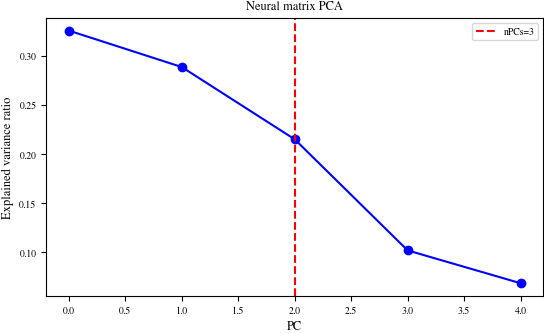

Neural matrix X shape: (2000, 3)


In [24]:
# ---- Build neural matrix X (mirrors cells 24) ---------------------------
sigT  = tensorX
permT, fitT = getPermutedTensor(factors, lambdas, sigT, NDIRS)
scld_permT  = permT

X_raw, _ = getNeuralMatrix(
    scld_permT, factors, lambdas, NDIRS,
    all_zeroed_stims=None, order='F', verbose=False)

# PCA to reduce to nPCs
pca_neural = PCA(len(lambdas))
pcaX       = pca_neural.fit_transform(X_raw)  # (N_all, R)

plt.plot(pca_neural.explained_variance_ratio_, 'bo-')
plt.axvline(nPCs - 1, color='red', linestyle='--', label=f'nPCs={nPCs}')
plt.xlabel('PC'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Neural matrix PCA'); plt.show()

X = pcaX[:, :nPCs]   # (N_all, nPCs)
print(f'Neural matrix X shape: {X.shape}')

In [25]:
# ---- Manual outlier removal (mirrors cells 26–27) -----------------------
# Adjust the slices below to match your encoding_manifolds.ipynb analysis.
D2_all = pwdists(X, sqdists=True)
N_all  = D2_all.shape[0]
D1_all = np.sqrt(D2_all)
mindists = np.min(D1_all + np.eye(N_all) * D1_all.max(), axis=0)

outls_far   = np.argsort(mindists)[::-1][:3]    # 3 most distant points
outls_close = np.argsort(mindists)[:37]          # 37 near-duplicate points

outliers_list = np.unique(np.append(outls_far, outls_close))
nonoutliers   = np.array([i for i in range(X.shape[0]) if i not in outliers_list])

# X_full: the PCA-reduced, outlier-filtered neural matrix — KEY INPUT
X_full = X[nonoutliers]   # shape (N_nonout, nPCs)
D2     = pwdists(X_full, sqdists=True)

print(f'X_full shape (N_nonout, nPCs): {X_full.shape}')
print(f'nonoutliers count: {len(nonoutliers)}')

X_full shape (N_nonout, nPCs): (1960, 3)
nonoutliers count: 1960


In [26]:
# ---- IAN graph (mirrors cell 29) ----------------------------------------
# Load precomputed wG if available (fast path), otherwise recompute (slow).

wG_path = f'{basedir_wG}/{PREFIX}_{R}.npy'

if os.path.exists(wG_path):
    print('Loading precomputed wG from', wG_path)
    wG_dense = np.load(wG_path)
    wG = csr_matrix(wG_dense)
    # Reconstruct binary adjacency from saved wG
    G  = (wG_dense > 0).astype(float)
    optScales = np.ones(X_full.shape[0])  # placeholder (not needed downstream)
    disc_pts  = []
else:
    print('Running IAN (this may take several minutes)...')
    solver = None  # set to 'GUROBI' for faster convergence
    G, wG, optScales, disc_pts = IAN('exact-precomputed-sq', D2, solver=solver)
    np.save(wG_path, wG.toarray())
    print('wG saved to', wG_path)

    # Handle any disconnected points from IAN
    wG, G, outliers_list, nonoutliers, _ = handle_disconnected_points(
        disc_pts, optScales, G, D2, outliers_list, neurons_used, X)
    X_full = X[nonoutliers]
    print(f'After IAN cleanup: {len(nonoutliers)} nonoutliers')

print(f'wG shape: {wG.shape}')

Loading precomputed wG from ../data/wG/fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1_5.npy
wG shape: (1987, 1987)


In [27]:
# ---- Diffusion maps + MDS embedding (mirrors cells 34–36) ---------------
diffmap_y, diffmap_evals = diffusionMapSparseK(csr_matrix(wG), 20, 1, t=1)
embedding_ = compute_mds_embedding(diffmap_y, nPCs, n_components=10)

# Pre-filter tensor to nonoutlier space so all subpop indexing is direct.
# Must come AFTER the IAN cell since that cell may update nonoutliers from cache.
tensor4d_nonout = tensor4d[nonoutliers]   # (N_nonout, S, D, T)

print(f'diffmap_y shape:  {diffmap_y.shape}')        # (N_nonout, 19)
print(f'embedding_ shape: {embedding_.shape}')       # (N_nonout, 10)
print(f'tensor4d_nonout:  {tensor4d_nonout.shape}')  # (N_nonout, S, D, T)

diffmap_y shape:  (1987, 20)
embedding_ shape: (1987, 10)
tensor4d_nonout:  (1960, 6, 8, 37)


Number of clusters: 1
Cluster label range: -1 to -1


/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:568: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


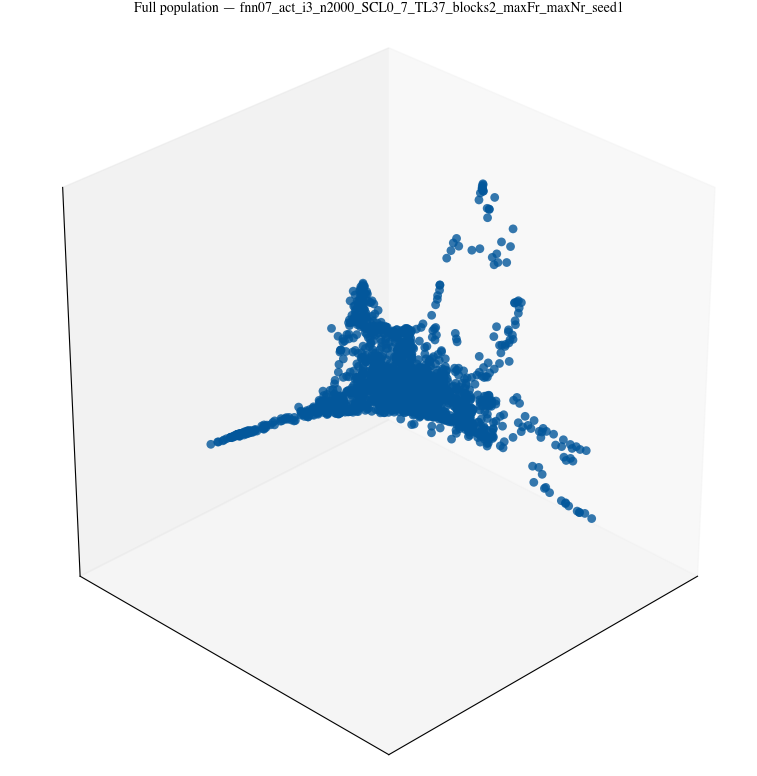

In [28]:
# ---- HDBSCAN clustering (for Method 2 cluster selection) ----------------
cluster_labels, num_clusters, cond_tree, leaves = run_hdbscan_clustering(
    diffmap_y, nPCs, G, min_cluster_size=10)

print(f'Number of clusters: {num_clusters}')
print(f'Cluster label range: {cluster_labels.min()} to {cluster_labels.max()}')

# Quick 3D embedding overview colored by cluster
fig_overview, ax_overview = plot_encoding_manifold_3d(
    embedding_, cluster_labels, PALETTE, dcs=(0, 1, 2),
    title=f'Full population — {PREFIX}')
plt.show()

## Section 2: Choose Subpopulation <a id='section-2'></a>

Run **one** of the subsections below (Method 1, 2a, 2b, or 2c), then run the
validation cell at the end of this section.

### Method 1 — Dynamic Filtering

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: divide by zero encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: overflow encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: invalid value encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/

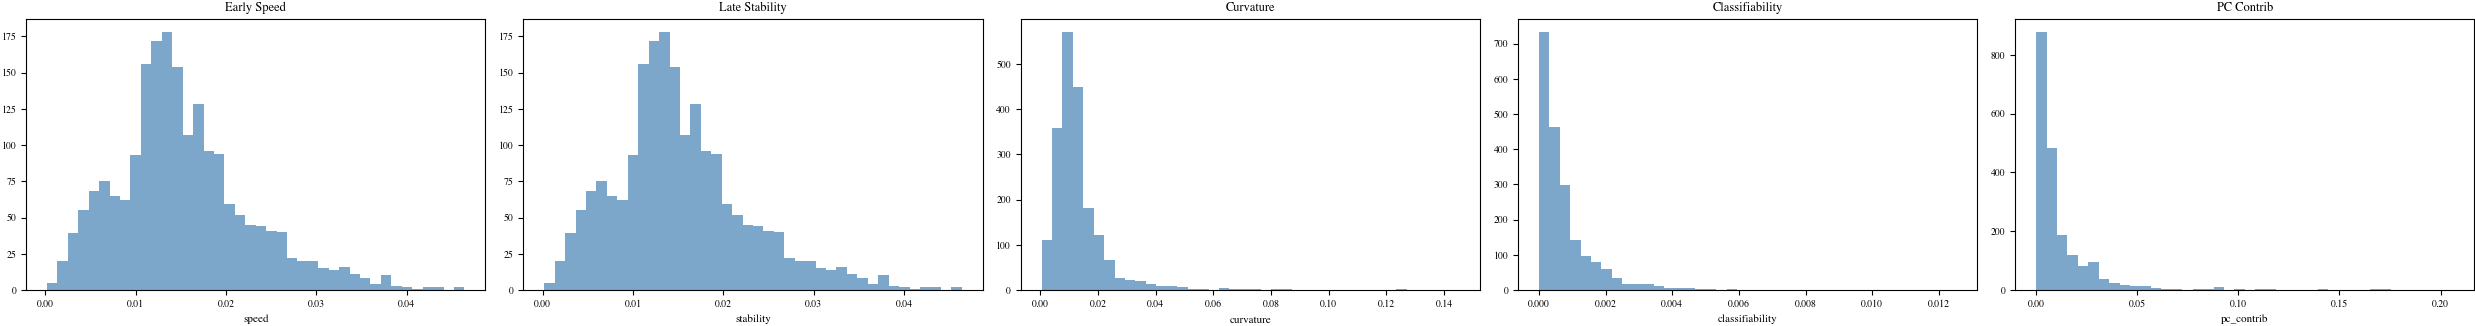

speed               : min=0.0002  max=0.0464  mean=0.0152
stability           : min=0.0002  max=0.0464  mean=0.0152
curvature           : min=0.0004  max=0.1452  mean=0.0137
classifiability     : min=0.0000  max=0.0125  mean=0.0008
pc_contrib          : min=0.0000  max=0.2065  mean=0.0120


In [29]:
# Compute per-neuron dynamic metrics over the full population (all N neurons).
# We remap to nonoutlier space in the filter cell below.
metrics = compute_dynamic_metrics(tensor4d, target_stim_idx=None)

# Inspect distributions (no selection yet)
fig_metrics, _ = plot_metric_distributions(metrics)
plt.show()

for k, v in metrics.items():
    print(f'{k:20s}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.4f}')

Selected 5 / 2000 neurons (full space)
After nonoutlier restriction: 4 neurons


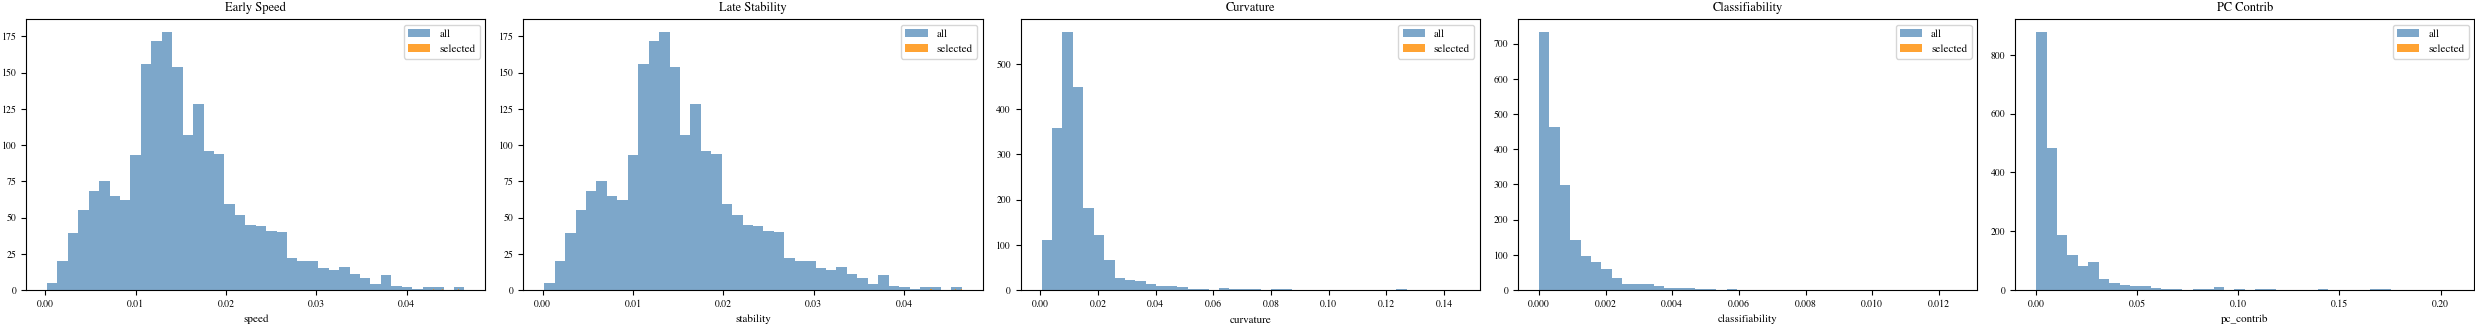

In [30]:
# --- Apply filter (edit as desired) ---
# Example: top 0.25% speed (tubular neurons, mirrors partial_decoding.ipynb idx_tubular)
selected_mask = filter_neurons_by_metric(metrics, 'speed', percentile_gt=99.75)

# Example compound filter (uncomment to use):
# selected_mask = (
#     filter_neurons_by_metric(metrics, 'speed', percentile_gt=99.75) &
#     filter_neurons_by_metric(metrics, 'stability', percentile_lt=50)
# )

# selected_mask is in full-population space (N neurons).
# Restrict to the nonoutlier set so subpop_indices align with tensor4d_nonout.
subpop_mask    = selected_mask[nonoutliers]          # nonoutlier-space bool, length N_nonout
subpop_indices = np.where(subpop_mask)[0]            # indices into tensor4d_nonout rows

print(f'Selected {selected_mask.sum()} / {len(selected_mask)} neurons (full space)')
print(f'After nonoutlier restriction: {subpop_mask.sum()} neurons')

# Overlay selected neurons on metric distributions (full-space mask for correct histograms)
fig_metrics2, _ = plot_metric_distributions(metrics, selected_mask)
plt.show()

### Method 2a — Cluster Selection

In [31]:
# Inspect cluster plot above, then set target cluster(s)
target_cluster = 0   # change after inspecting the overview plot

subpop_mask    = select_neurons_by_cluster(cluster_labels, target_cluster)
subpop_indices = np.where(subpop_mask)[0]

print(f'Cluster {target_cluster}: {subpop_mask.sum()} neurons selected')

Cluster 0: 0 neurons selected


### Method 2b — Bounding Box

In [32]:
# Define bounding box in embedding space (dim index → (min, max))
bounds = {0: (-0.2, 0.2), 1: (0.05, 0.4)}

subpop_mask    = select_neurons_by_bbox(embedding_, bounds)
subpop_indices = np.where(subpop_mask)[0]

print(f'Bounding box selection: {subpop_mask.sum()} neurons')

Bounding box selection: 240 neurons


### Method 2c — Seed + Radius

In [33]:
seed_idx = 42    # index in nonoutlier space
radius   = 0.15

subpop_mask    = select_neurons_by_radius(embedding_, seed_idx, radius)
subpop_indices = np.where(subpop_mask)[0]

print(f'Radius selection (seed={seed_idx}, r={radius}): {subpop_mask.sum()} neurons')

Radius selection (seed=42, r=0.15): 1722 neurons


### Validation — Where does the subpopulation sit?

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:437: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


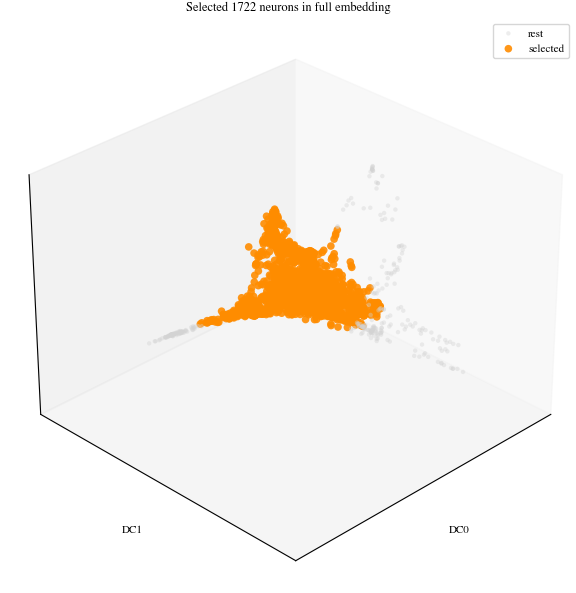

Subpopulation size in nonoutlier space: 1722


In [34]:
# 3D scatter: rest in gray, selected highlighted
fig_loc, ax_loc = plot_neuron_locations_in_manifold(
    embedding_, subpop_mask, dcs=(0, 1, 2))
ax_loc.set_title(f'Selected {subpop_mask.sum()} neurons in full embedding')
plt.show()

print(f'Subpopulation size in nonoutlier space: {len(subpop_indices)}')

## Section 3: Decoding Analysis <a id='section-3'></a>

In [35]:
# subpop_indices are in nonoutlier space (0..N_nonout-1).
# tensor4d_nonout is already filtered to nonoutlier space, so index directly.
print(subpop_indices)
tensor4d_sub = tensor4d_nonout[subpop_indices]   # (K, S, D, T)

print(f'tensor4d_sub shape: {tensor4d_sub.shape}')

[   0    1    2 ... 1983 1984 1986]


IndexError: index 1960 is out of bounds for axis 0 with size 1960

Decoding manifold coords shape: (48, 3)
Explained variance (3 PCs): 0.882


/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:479: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


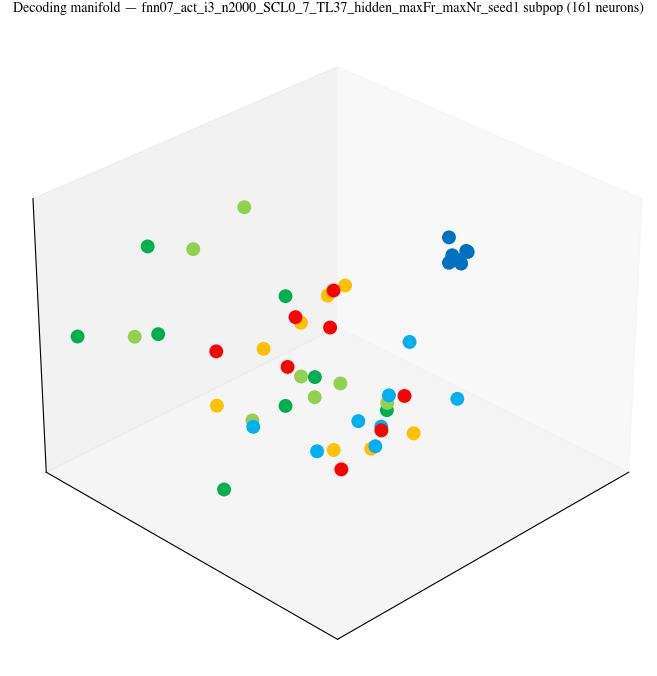

In [ ]:
# ---- Decoding manifold --------------------------------------------------
coords, pca_dec = compute_decoding_manifold(tensor4d_sub, n_components=3)

print(f'Decoding manifold coords shape: {coords.shape}')
print(f'Explained variance (3 PCs): {pca_dec.explained_variance_ratio_.sum():.3f}')

fig_dec, ax_dec = plot_decoding_manifold(
    coords, N_STIM, N_DIR, STIMULUS_COLORS, LABELS,
    title=f'Decoding manifold — {PREFIX} subpop ({len(subpop_indices)} neurons)')
plt.savefig(f'{basedir_fig}/decoding_manifolds/{PREFIX}_subpop_decoding.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Trajectories shape: (48, 37, 3)


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/pyth

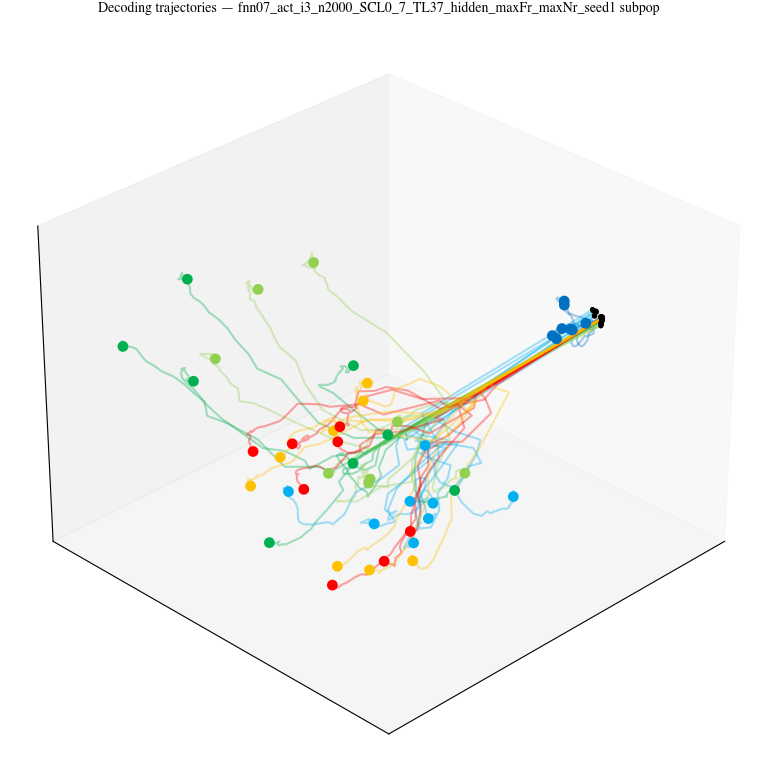

In [ ]:
# ---- Decoding trajectories ----------------------------------------------
trajs, pca_traj = compute_decoding_trajectories(tensor4d_sub, n_components=3)

print(f'Trajectories shape: {trajs.shape}')  # (S*D, T, 3)

fig_traj, ax_traj = plot_decoding_trajectories(
    trajs, N_STIM, N_DIR, STIMULUS_COLORS,
    title=f'Decoding trajectories — {PREFIX} subpop')
plt.savefig(f'{basedir_fig}/decoding_trajectories/crossings_{PREFIX}_subpop.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## Section 4: Encoding Analysis <a id='section-4'></a>

### Fast path — visualize subpop in existing embedding (instant)

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:568: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


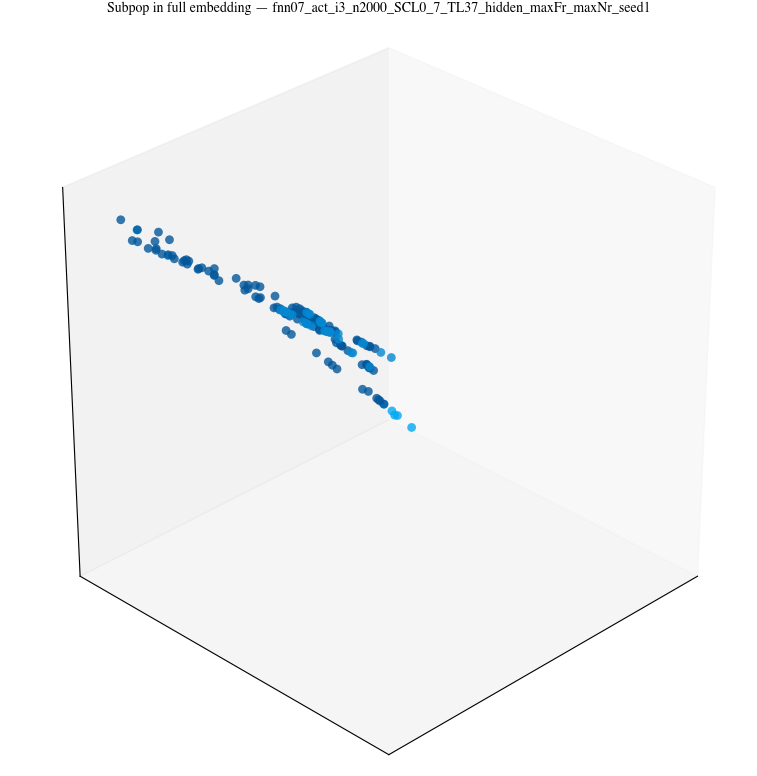

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:608: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


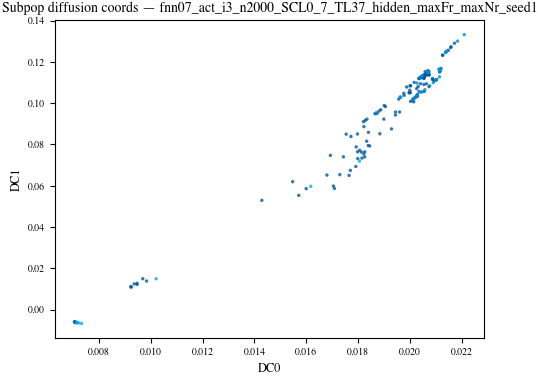

In [ ]:
# Show only the subpopulation's rows in the full embedding (no IAN re-run).
# Useful for quickly seeing where the subpop sits in the encoding manifold.

sub_embedding = embedding_[subpop_indices]   # (K, 10)

# Color by cluster labels of the subpop
sub_cluster_labels = cluster_labels[subpop_indices]

fig_sub3d, ax_sub3d = plot_encoding_manifold_3d(
    sub_embedding, sub_cluster_labels, PALETTE,
    title=f'Subpop in full embedding — {PREFIX}')
plt.show()

fig_sub2d, ax_sub2d = plot_encoding_manifold_2d(
    diffmap_y[subpop_indices], sub_cluster_labels, PALETTE,
    title=f'Subpop diffusion coords — {PREFIX}')
plt.show()

### Full rebuild — fresh manifold from subpopulation only (minutes)

This re-runs IAN + diffusion maps + MDS on just the subpopulation.
Best for subpopulations of ≥ ~50 neurons.

Running IAN on 161 neurons...
### Iteration 1 done. (0.06 s) - pruned 1 edge(s)
### Iteration 2 done. (0.01 s) - pruned 1 edge(s)
### Iteration 3 done. (0.01 s) - pruned 1 edge(s)
### Iteration 4 done. (0.01 s) - pruned 1 edge(s)
### Iteration 5 done. (0.01 s) - pruned 1 edge(s)
### Iteration 6 done. (0.01 s) - pruned 1 edge(s)
### Iteration 7 done. (0.01 s) - pruned 1 edge(s)
### Iteration 8 done. (0.01 s) - pruned 1 edge(s)
### Iteration 9 done. (0.01 s) - pruned 1 edge(s)
### Iteration 10 done. (0.01 s) - pruned 1 edge(s)
### Iteration 11 done. (0.01 s) - pruned 1 edge(s)
### Iteration 12 done. (0.01 s) - pruned 1 edge(s)
### Iteration 13 done. (0.01 s) - pruned 1 edge(s)
### Iteration 14 done. (0.01 s) - pruned 1 edge(s)
CONVERGED: no change in unweighted graph.
Total # edges pruned: 14, (0 disconnected points)
C-tuning weighted graph...
Unweighted graph stats: mean=1.294, median=0.954
Weighted graph stats: mean=1.062, median=0.996


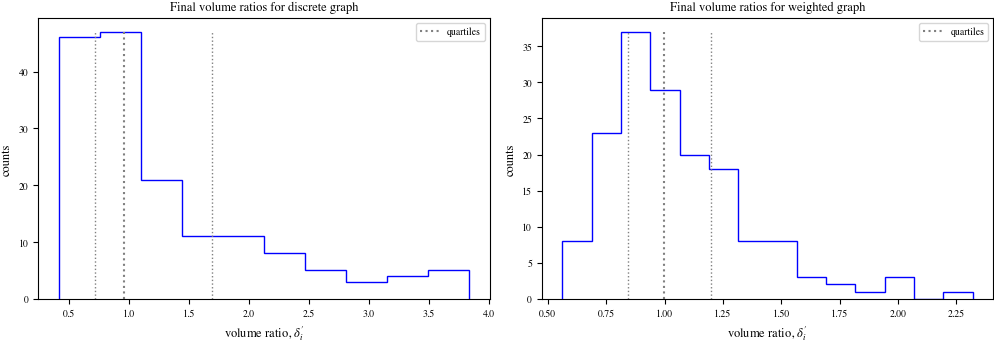

X_sub shape:      (161, 3)
nonoutliers:      161 clean neurons
embedding_ shape: (161, 10)


In [ ]:
print(f'Running IAN on {len(subpop_indices)} neurons...')

enc = build_encoding_manifold_for_subpop(
    X_full, subpop_indices, nPCs=nPCs,
    solver=None,              # set 'GUROBI' for faster convergence
    n_diffmap_components=20,
    n_mds_components=10
)

print(f"X_sub shape:      {enc['X_sub'].shape}")
print(f"nonoutliers:      {len(enc['nonoutliers'])} clean neurons")
print(f"embedding_ shape: {enc['embedding_'].shape}")

Subpop clusters: 6


/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:568: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


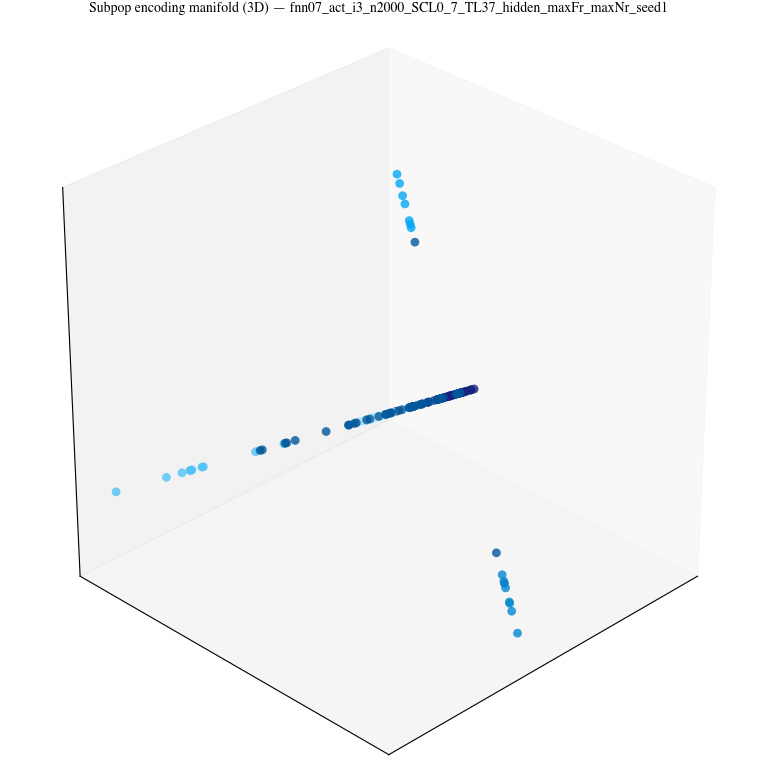

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:608: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


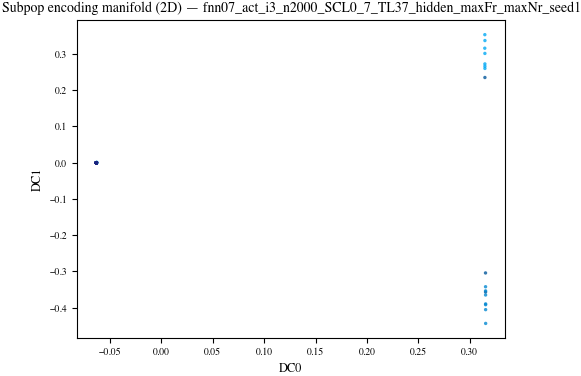

In [ ]:
# Cluster the subpop encoding manifold
sub_labels, sub_n_clusters, sub_cond_tree, sub_leaves = run_hdbscan_clustering(
    enc['diffmap_y'], nPCs, enc['G'], min_cluster_size=5)

print(f'Subpop clusters: {sub_n_clusters}')

fig_enc3d, ax_enc3d = plot_encoding_manifold_3d(
    enc['embedding_'], sub_labels, PALETTE,
    title=f'Subpop encoding manifold (3D) — {PREFIX}')
plt.show()

fig_enc2d, ax_enc2d = plot_encoding_manifold_2d(
    enc['diffmap_y'], sub_labels, PALETTE,
    title=f'Subpop encoding manifold (2D) — {PREFIX}')
plt.show()

## Section 5: Side-by-Side Comparison (optional) <a id='section-5'></a>

Full population vs. subpopulation for decoding and encoding manifolds.

Full pop decoding manifold explained variance: 0.527


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-

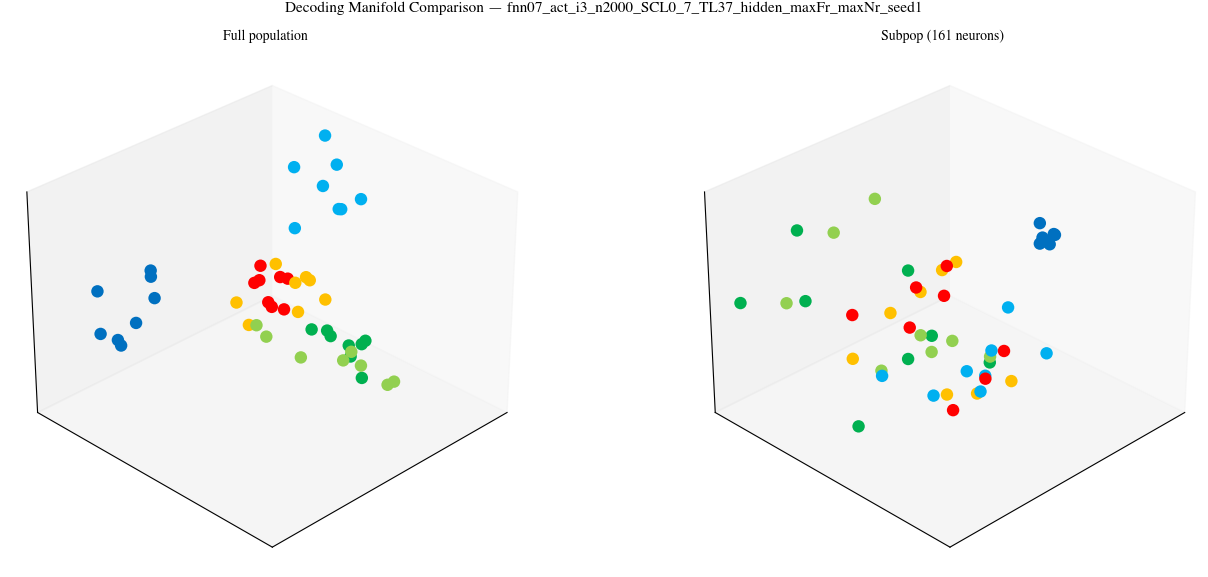

In [ ]:
# ---- Full-population decoding manifold ----------------------------------
coords_full, pca_full = compute_decoding_manifold(tensor4d, n_components=3)
print(f'Full pop decoding manifold explained variance: '
      f'{pca_full.explained_variance_ratio_.sum():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={'projection': '3d'})

clrs = np.array([c for c in STIMULUS_COLORS for _ in range(N_DIR)])
lbls = np.array([lb for lb in LABELS for _ in range(N_DIR)])

for ax, coords_plot, title in [
        (axes[0], coords_full, 'Full population'),
        (axes[1], coords,      f'Subpop ({len(subpop_indices)} neurons)')]:
    for i, label in enumerate(LABELS):
        mask = lbls == label
        ax.scatter(coords_plot[mask, 0], coords_plot[mask, 1], coords_plot[mask, 2],
                   color=STIMULUS_COLORS[i], s=80, edgecolors='none', depthshade=False,
                   label=label)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False); ax.view_init(elev=30, azim=45)
    ax.set_title(title, fontsize=10)

fig.suptitle(f'Decoding Manifold Comparison — {PREFIX}', fontsize=11)
fig.tight_layout()
plt.savefig(f'{basedir_fig}/decoding_manifolds/{PREFIX}_comparison.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_10924/1222010772.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


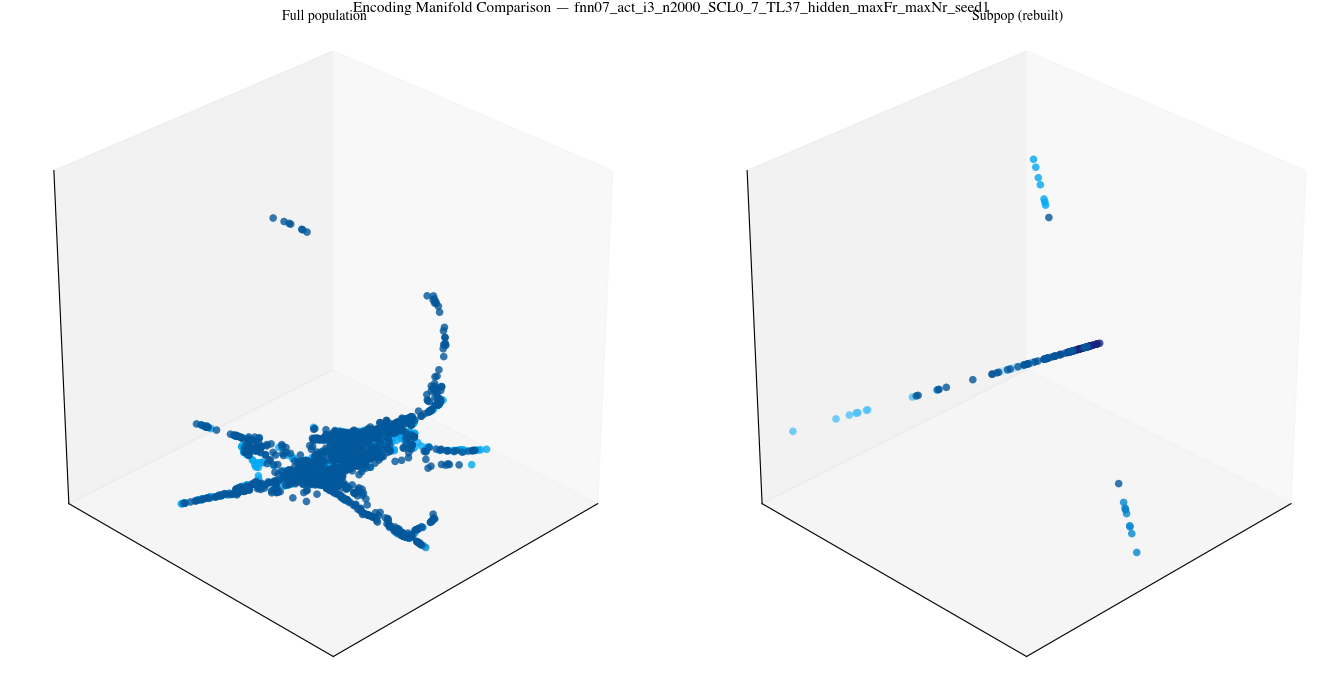

In [ ]:
# ---- Full-population vs subpop encoding manifold (3D) -------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                         subplot_kw={'projection': '3d'})

for ax, emb, lbls_plot, title in [
        (axes[0], embedding_,     cluster_labels,  'Full population'),
        (axes[1], enc['embedding_'], sub_labels,   f'Subpop (rebuilt)')
        ]:
    ulbls = np.unique(lbls_plot)
    pal   = PALETTE
    while len(pal) < len(ulbls):
        pal = np.r_[pal, pal]
    for fi, lbl in enumerate(ulbls):
        mask = lbls_plot == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1], emb[mask, 2],
                   c=pal[fi % len(pal)], s=30, alpha=0.8,
                   edgecolors='none', depthshade=False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False); ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=30, azim=45)
    ax.set_title(title, fontsize=10)

fig.suptitle(f'Encoding Manifold Comparison — {PREFIX}', fontsize=11)
fig.tight_layout()
plt.savefig(f'{basedir_fig}/3d_manifolds/{PREFIX}_subpop_comparison.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()